# Zhang et al. M0=5 radiative shock: reading & analytic fit

`RadHydroZhangMach5` (grey diffusion, Zhang et al. constant gray opacities $\sigma_\mathrm{ross}=0.848903$, $\sigma_\mathrm{abs}=3.92664\times10^{-5}\,\mathrm{cm^{-1}}$) snapshots loaded with `richio`, compared against the analytic NLTE radiative-shock solution (Lowrie & Edwards 2008) from `analysis_files/radiative_shock`.

This is the Zhang et al. case from `nlte_radiative_shock.py`'s demo block at its **actual M0=5** -- note `RadHydroMach2` uses the same opacity/density scale but a reduced `v_left` giving M0$\approx$2. The M0=5 shock has a much longer upstream precursor (~3765 cm), hence the wider box.

**Frame:** the sim is run in the shock-stationary frame (both states have `v_shock` subtracted so the shock stays put on the Eulerian mesh), while the analytic solver works in the lab frame. Sim positions are therefore mapped as $x_\mathrm{lab} = x_\mathrm{sim} + v_\mathrm{shock} t$ before calling `solve_profiles`, and the analytic velocity is shifted back by $-v_\mathrm{shock}$ for plotting.

**Caveat:** as of the first pass (Np=4096, $t_\mathrm{end}=0.05$ s) this run is *not* fully converged -- final L1 errors are ~5% (density) / ~8% (temperatures), still slowly decreasing at the end of the run rather than plateaued. Expect the L1-vs-time panel below to sit above the 2.5% line.

This run uses **raw cgs units directly**, not richio's Msun/Rsun/G=1 code-unit system used for TDE runs -- so fields are taken as bare floats out of the `unyt_array` (never `.in_cgs()`/`.to(...)`, which would apply the wrong scale).

Batch version (scans every snapshot, writes the summary table + per-snapshot figures) lives in `scripts/zhang_mach5_radiative_shock_scan.py` -- rerun that to refresh after a new sim, tune/explore here.

In [1]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

import richio
import richio.shockfinder as sf

sys.path.insert(0, os.path.abspath("../../scripts"))
from nlte_radiative_shock import NLTERadiativeShock
from radiative_shock import Units

## Config

Left (unshocked, downstream) state and opacities -- must match `runs/RadHydroZhangMach5/test.cpp`.

In [2]:
INPUT_DIR = "/home/hey4/RICH/alice_data/raw/RadHydroZhangMach5"

GAMMA = 5.0 / 3.0
MU = 1.67e-24  # g, mean particle mass
K_BOLTZ = 1.380649e-16  # erg/K
CV = K_BOLTZ / (MU * (GAMMA - 1.0))

RHO_LEFT = 5.45969e-13  # g/cc
V_LEFT = 5.88588e5  # cm/s (analytic lab frame, M0=5)
T_LEFT = 100.0  # K
SIGMA_ROSS = 0.848903  # 1/cm
SIGMA_ABS = 3.92664e-5  # 1/cm

CS_LEFT = np.sqrt(GAMMA * (GAMMA - 1.0) * CV * T_LEFT)
M0 = V_LEFT / CS_LEFT

solver = NLTERadiativeShock(
    M0=M0,
    gamma=GAMMA,
    sigma_ross=lambda T, rho: SIGMA_ROSS,
    sigma_abs=lambda T, rho: SIGMA_ABS,
    cv=CV,
    rho_left=RHO_LEFT,
    v_left=V_LEFT,
    T_left=T_LEFT,
    eps_nlte_solver=0.5e-4,
)
print(f"M0 = {solver.M0:.4f}, v_shock = {solver.v_shock:.4e} cm/s")
print(f"analytic profile spans {solver.x_profile.min():.4e} .. {solver.x_profile.max():.4e} cm")

INFO:RadiativeShock:creating a RadiativeShock calculator...


INFO:RadiativeShock:gamma=1.66667


INFO:RadiativeShock:M0=5.01422


INFO:RadiativeShock:P0=0.00010057


INFO:RadiativeShock:downstream (unshocked, left) state: rho=5.45969e-13[g/cc] T=100[K]=8.617333e-06[keV] v=588588[cm/s]


...

INFO:RadiativeShock:radiation ideal gas (gamma=4/3) dominated compression 5.74557


INFO:RadiativeShock:calculated mach=(v_shock-v_left)/cs_left=5.01422 while given mach M0=5.01422 err=0


INFO:NLTERadiativeShock:creating a NLTERadiativeShock calculator...


Precursor region
Relaxation region
Discontinuous case: embedded hydrodynamic shock
M0 = 5.0142, v_shock = 0.0000e+00 cm/s
analytic profile spans -3.7894e+03 .. 1.8979e+01 cm


/zfsstore/user/hey4/rich_tde/scripts/Noebauer_nlte_solver.py:558: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  res = scipy.integrate.odeint(func, func0, Minteg)


## Load one snapshot

Pick any `ZhangM5_*.h5` file -- change `SNAP` and rerun.

In [3]:
files = sorted(glob.glob(os.path.join(INPUT_DIR, "ZhangM5_*.h5")))
print(f"{len(files)} snapshots available, e.g.:")
print([os.path.basename(f) for f in files[:5]], "...")

SNAP = "ZhangM5_final.h5"
snap = richio.load(os.path.join(INPUT_DIR, SNAP))

# Raw cgs values (see note above -- no unit conversion)
x_num = np.asarray(snap.x)
rho_num = np.asarray(snap.density)
T_num = np.asarray(snap.temperature)
Erad_num = np.asarray(snap.Erad)  # specific radiation energy [erg/g]
Trad_num = (Erad_num * rho_num / Units.arad) ** 0.25
diss_num = np.asarray(snap.dissipation * snap.volume)
t = float(np.asarray(snap.time))

order = np.argsort(x_num)
x_num, rho_num, T_num, Trad_num, diss_num = (
    x_num[order], rho_num[order], T_num[order], Trad_num[order], diss_num[order],
)

print(f"{SNAP}: t={t:.4e}s, {len(x_num)} cells")

588 snapshots available, e.g.:
['ZhangM5_0.h5', 'ZhangM5_100.h5', 'ZhangM5_1000.h5', 'ZhangM5_10000.h5', 'ZhangM5_10100.h5'] ...
ZhangM5_final.h5: t=5.0000e-02s, 4096 cells


## Analytic fit at this snapshot's time

In [4]:
# Sim runs in the shock-stationary frame; map to the analytic lab frame.
V_SHOCK = solver.v_shock
x_lab = x_num + V_SHOCK * t
solution = solver.solve_profiles(time=t, x=x_lab)
v_ana = solution["velocity"] - V_SHOCK  # back into sim frame for plotting
rho_ana = solution["density"]
T_ana = solution["temperature"]
Trad_ana = solution["radiation_temperature"]


def rel_l1_error(numeric, analytic):
    """Per-cell relative L1 error: mean(|num - ana| / |num|), shocked region only."""
    mask = np.abs(numeric) > 0.01 * np.max(np.abs(numeric))
    if np.sum(mask) < 2:
        mask = np.ones(len(numeric), dtype=bool)
    return float(np.mean(np.abs(numeric[mask] - analytic[mask]) / np.abs(numeric[mask])))


print(f"density_L1 = {rel_l1_error(rho_num, rho_ana):.4e}")
print(f"Tgas_L1    = {rel_l1_error(T_num, T_ana):.4e}")
print(f"Trad_L1    = {rel_l1_error(Trad_num, Trad_ana):.4e}")

density_L1 = 5.1896e-02
Tgas_L1    = 8.2937e-02
Trad_L1    = 7.5544e-02


## Profile comparison plot

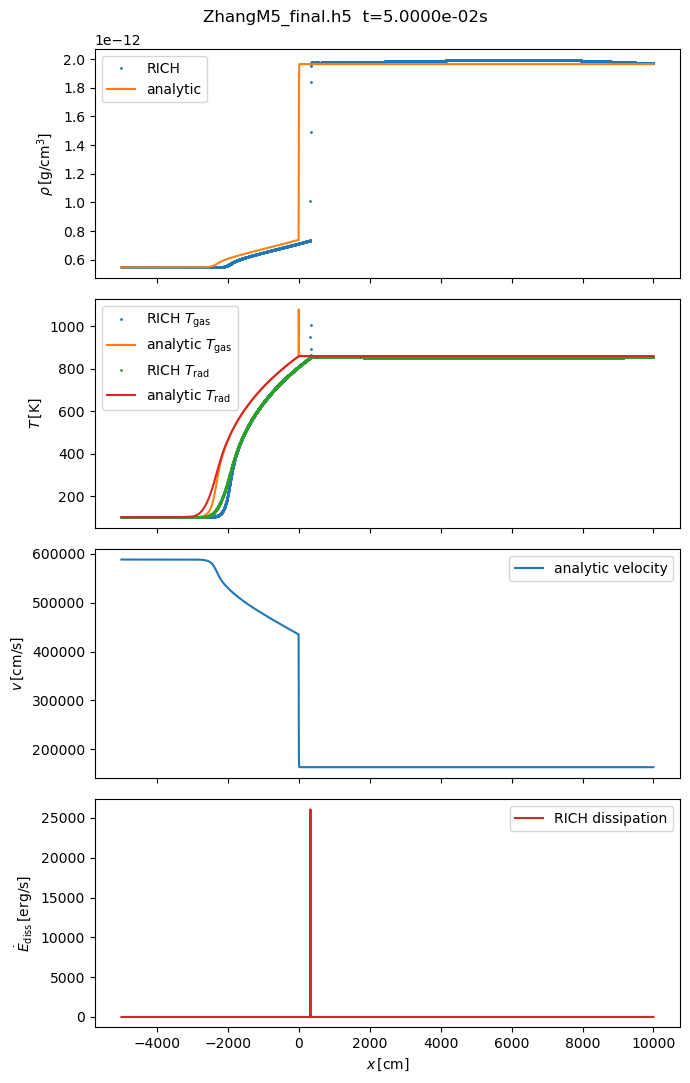

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(7, 11), sharex=True)

axes[0].plot(x_num, rho_num, ".", ms=2, label="RICH")
axes[0].plot(x_num, rho_ana, "-", label="analytic")
axes[0].set_ylabel(r"$\rho\,\mathrm{[g/cm^3]}$")
axes[0].legend()

axes[1].plot(x_num, T_num, ".", ms=2, label=r"RICH $T_\mathrm{gas}$")
axes[1].plot(x_num, T_ana, "-", label=r"analytic $T_\mathrm{gas}$")
axes[1].plot(x_num, Trad_num, ".", ms=2, label=r"RICH $T_\mathrm{rad}$")
axes[1].plot(x_num, Trad_ana, "-", label=r"analytic $T_\mathrm{rad}$")
axes[1].set_ylabel(r"$T\,\mathrm{[K]}$")
axes[1].legend()

axes[2].plot(x_num, v_ana, "-", label="analytic velocity")
axes[2].set_ylabel(r"$v\,\mathrm{[cm/s]}$")
axes[2].legend()

axes[3].plot(x_num, diss_num, "-", ms=2, color="C3", label="RICH dissipation")
axes[3].set_ylabel(r"$\dot{E}_\mathrm{diss}\,\mathrm{[erg/s]}$")
axes[3].set_xlabel(r"$x\,\mathrm{[cm]}$")
axes[3].legend()

fig.suptitle(f"{SNAP}  t={t:.4e}s")
fig.tight_layout()
plt.show()

## Robustness of the momentum-jump Mach number

For every pair of cells $(i,j)$ in the profile, treat cell $i$ as the preshock state and cell $j$ as the postshock state and evaluate the momentum-flux Mach number

$$\dot{M}^2 = \frac{p_j - p_i}{1/\rho_i - 1/\rho_j}, \qquad \mathcal{M}_0 = \frac{\dot{M}}{\rho_i c_{s,i}}$$

using the *total* (gas + radiation) pressure. Only $x_i < x_j$ is physical (preshock upstream of postshock), so the reversed half of the grid is masked out. This shows how sensitive a recovered Mach number is to which pair of states you pick -- relevant when a shock finder has to choose pre/post cells itself.

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


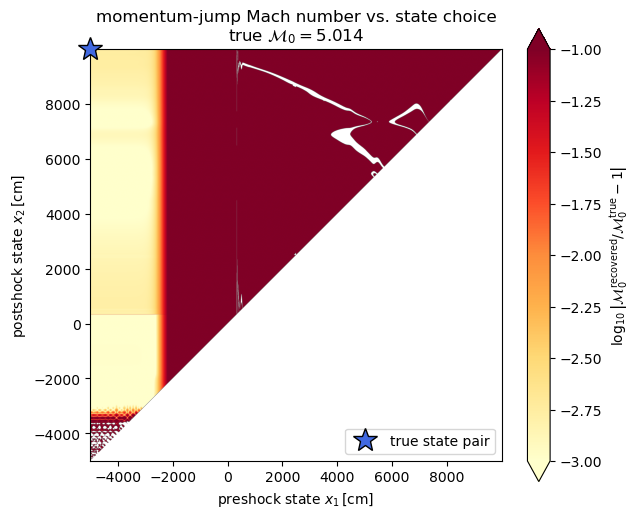

In [6]:
def total_pressure(rho, T, Erad):
    """Gas pressure (ideal-gas EOS) + radiation pressure P_rad = U_rad/3, using
    the radiation energy density directly from the sim (rho*Erad) rather than
    reconstructing it via a temperature. T_gas != T_rad out of LTE, so going
    through T**4 would be an unnecessary (and error-prone) round-trip."""
    return (GAMMA - 1.0) * rho * CV * T + rho * Erad / 3.0


def sound_speed(T):
    return np.sqrt(GAMMA * (GAMMA - 1.0) * CV * T)


p_num = total_pressure(rho_num, T_num, Erad_num)
cs_num = sound_speed(T_num)

rhoA, rhoB = rho_num[:, None], rho_num[None, :]  # rows=preshock i, cols=postshock j
pA, pB = p_num[:, None], p_num[None, :]
csA = cs_num[:, None]

with np.errstate(divide="ignore", invalid="ignore"):
    Mdot2 = (pB - pA) / (1.0 / rhoA - 1.0 / rhoB)
    M0_grid = np.sqrt(Mdot2) / (rhoA * csA)

i_idx, j_idx = np.meshgrid(np.arange(len(x_num)), np.arange(len(x_num)), indexing="ij")
valid = (j_idx > i_idx) & (Mdot2 > 0) & np.isfinite(M0_grid)
M0_grid = np.where(valid, M0_grid, np.nan)

rel_err = np.abs(M0_grid / solver.M0 - 1.0)
log_rel_err = np.log10(np.maximum(rel_err, 1e-6))
VMIN, VMAX = -3.0, -1.0

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(
    log_rel_err.T,  # transpose: rows(j)->y=postshock, cols(i)->x=preshock
    origin="lower",
    extent=[x_num[0], x_num[-1], x_num[0], x_num[-1]],
    aspect="equal",
    cmap="YlOrRd",
    vmin=VMIN,
    vmax=VMAX,
)
ax.plot(x_num[0], x_num[-1], "*", ms=18, mec="k", mfc="royalblue", label="true state pair", zorder=5, clip_on=False)

cbar = fig.colorbar(im, ax=ax, extend="both", label=r"$\log_{10}\left|\mathcal{M}_0^\mathrm{recovered}/\mathcal{M}_0^\mathrm{true} - 1\right|$")

ax.set_xlabel(r"preshock state $x_1\,\mathrm{[cm]}$")
ax.set_ylabel(r"postshock state $x_2\,\mathrm{[cm]}$")
ax.set_title(f"momentum-jump Mach number vs. state choice\ntrue $\\mathcal{{M}}_0={solver.M0:.3f}$")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## Shock finder

Run with the finder's **default** `mach_min=1.3` thresholds -- see the note below the output for why this regime is hard for it.

In [7]:
# No actual voronoi tessellation in 1D
vor = sf.build_voronoi(snap, coords=("X",))
shock_zone = sf.find_shock_zone(snap, vor)
surface = sf.find_shock_surface(snap, vor, shock_zone)

# Finder masks are in snap's native cell order; reorder to the x-sorted profiles.
zone_s = shock_zone[order]
surf_s = surface.surface_mask[order]
pre_s = surface.pre_mask[order]
post_s = surface.post_mask[order]
divV_s = np.asarray(snap.divV)[order]
v_num = np.asarray(snap.Vx)[order]

print(f"shock-zone cells : {int(shock_zone.sum())}")
print(f"surface cells    : {int(surface.surface_mask.sum())}")
print(f"surface x [cm]   : {np.round(x_num[surf_s], 4)}")
for name in ("mach_T", "mach_P", "mach_rho"):
    m = getattr(surface, name)
    m = m[np.isfinite(m)]
    print(f"  {name:9s} median = {np.median(m):.3f}" if m.size else f"  {name:9s} (none)")
print(f"analytic upstream Mach M0 = {solver.M0:.3f}")

# How far is condition 3 from firing? It samples a 2-cell stencil (the
# neighbours at +/-ds) and needs BOTH the T and P jump over thresholds.
T_s = (rho_num * 0 + np.asarray(snap.P)[order]) / rho_num
P_s = np.asarray(snap.P)[order]
dlogT = np.abs(np.log10(T_s[2:] / T_s[:-2]))
dlogP = np.abs(np.log10(P_s[2:] / P_s[:-2]))
print(f"\nbest 2-cell stencil jump: dlogT={dlogT.max():.4f} (needs >=0.11), dlogP={dlogP.max():.4f} (needs >=0.27)")

Building Voronoi for 4,096 cells (1D) ...


Done.  Mean neighbours/cell: 2.0


shock-zone cells : 0
surface cells    : 0
surface x [cm]   : []
  mach_T    (none)
  mach_P    (none)
  mach_rho  (none)
analytic upstream Mach M0 = 5.014

best 2-cell stencil jump: dlogT=0.0727 (needs >=0.11), dlogP=0.3793 (needs >=0.27)


**The finder returns nothing here, and that is the expected answer -- not a bug to tune away.**

Conditions 1 and 2 (converging flow, $\nabla T\cdot\nabla P>0$) pass on ~1400 cells. Condition 3 is what fails: it samples a 2-cell stencil and requires $\Delta\log_{10}T\ge0.11$ *and* $\Delta\log_{10}P\ge0.27$ at the same cell. Those thresholds come from the adiabatic Rankine-Hugoniot relations at $M=1.3$, i.e. they assume the whole jump is concentrated across ~one or two cells.

This is the most extreme case of the three: the radiative precursor spreads the transition over ~600 cells, so although the *global* jump is huge (a factor ~31 in pressure, ~10 in temperature) the *local* per-stencil temperature jump is only $\approx0.07$ against the 0.11 required. The pressure criterion passes comfortably ($\approx0.38$); temperature is the binding one, since radiation pre-heats the upstream gas and flattens $\nabla T$.

Note the resolution irony: this run has 4096 cells (4x `RadHydroMach2`) and so fails *harder*, because finer cells mean smaller per-stencil jumps. A Schaal+14-style finder systematically under-reports diffusion-smeared radiative shocks; detecting them would need a criterion evaluated over the physical diffusion length rather than a fixed cell stencil.

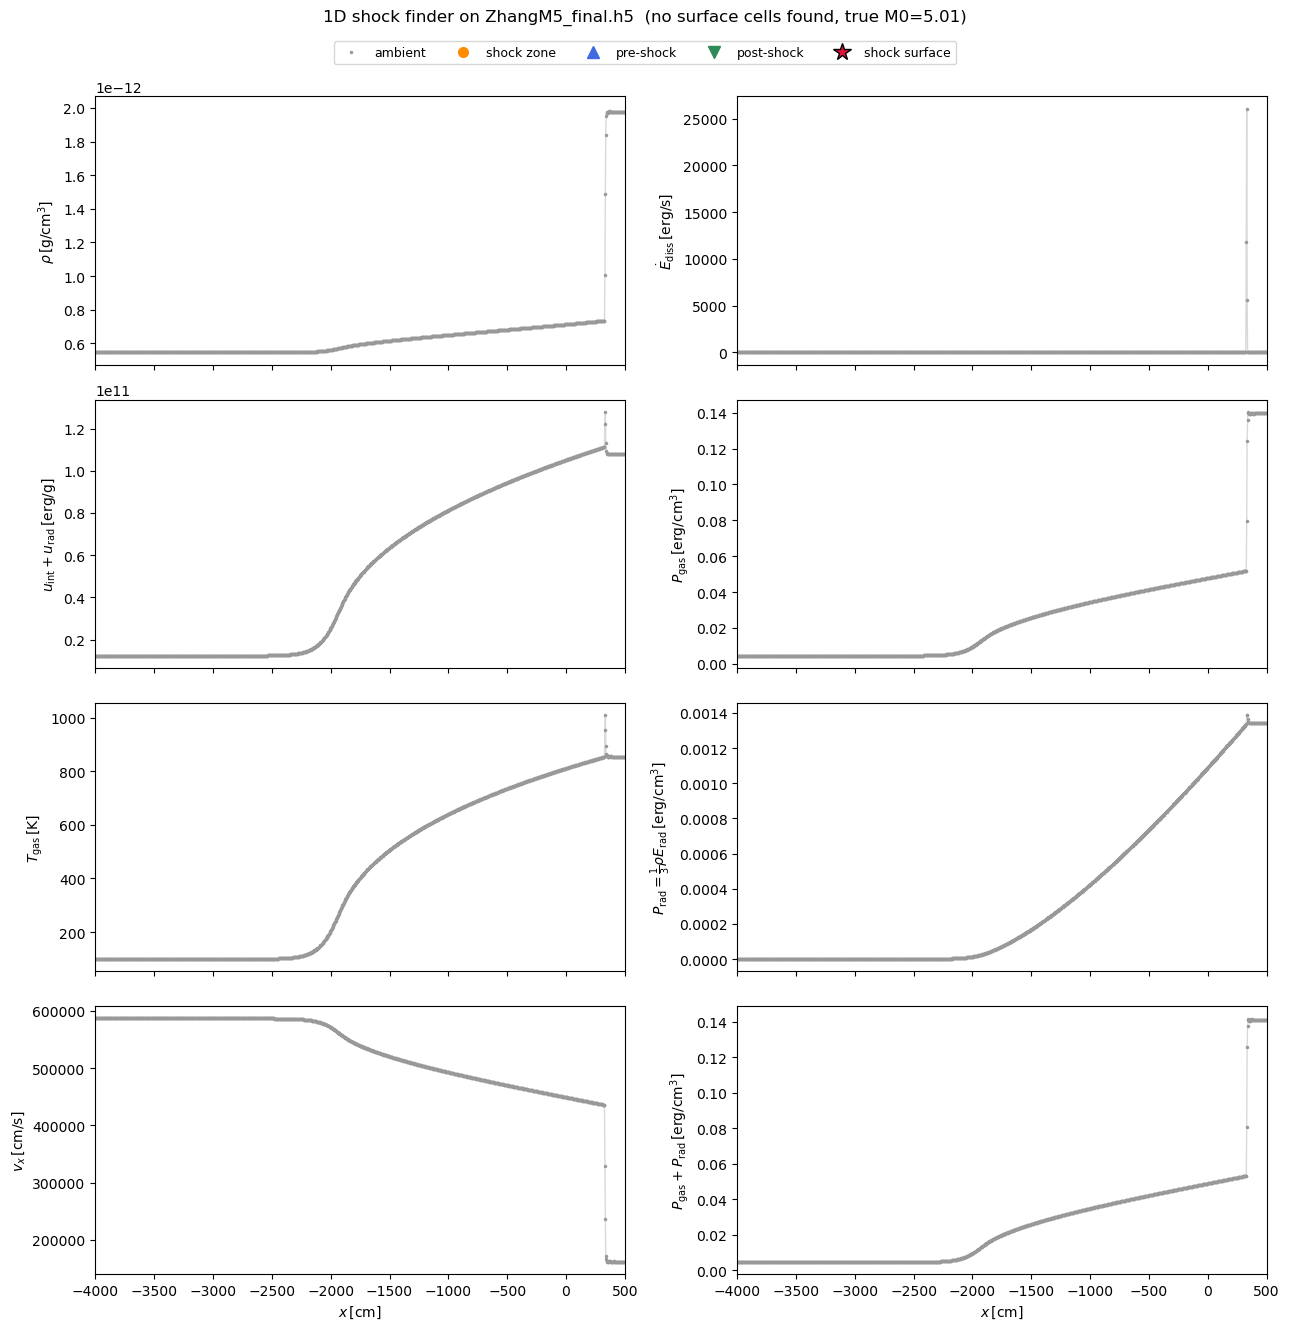

In [8]:
# Gas / radiation pressure from the x-sorted profiles.
Pgas = (GAMMA - 1.0) * rho_num * CV * T_num
Prad = rho_num * Erad_num / 3.0  # P_rad = U_rad/3, direct from the sim field (not via T**4)
Ptot = Pgas + Prad

# Specific internal and radiation energy, straight from the snapshot fields
# (both [erg/g]); reordered to the x-sorted profiles.
u_int = np.asarray(snap.InternalEnergy)[order]
u_rad = np.asarray(snap.Erad)[order]
u_tot = u_int + u_rad


def mark_states(ax, y):
    """Overlay the shock finder's per-cell state on a profile panel."""
    ax.plot(x_num, y, "-", color="0.85", lw=1, zorder=1)
    ax.plot(x_num, y, ".", color="0.6", ms=3, label="ambient", zorder=2)
    ax.plot(x_num[zone_s], y[zone_s], "o", color="darkorange", ms=7, label="shock zone", zorder=3)
    ax.plot(x_num[pre_s], y[pre_s], "^", color="royalblue", ms=8, label="pre-shock", zorder=4)
    ax.plot(x_num[post_s], y[post_s], "v", color="seagreen", ms=8, label="post-shock", zorder=4)
    ax.plot(x_num[surf_s], y[surf_s], "*", color="crimson", ms=13, mec="k", label="shock surface", zorder=5)
    for xs in x_num[surf_s]:
        ax.axvline(xs, color="crimson", lw=0.8, ls="--", alpha=0.5, zorder=0)


panels = [
    (rho_num, r"$\rho\,\mathrm{[g/cm^3]}$"),
    (u_tot, r"$u_\mathrm{int}+u_\mathrm{rad}\,\mathrm{[erg/g]}$"),
    (T_num, r"$T_\mathrm{gas}\,\mathrm{[K]}$"),
    (v_num, r"$v_x\,\mathrm{[cm/s]}$"),
    (diss_num, r"$\dot{E}_\mathrm{diss}\,\mathrm{[erg/s]}$"),
    (Pgas, r"$P_\mathrm{gas}\,\mathrm{[erg/cm^3]}$"),
    (Prad, r"$P_\mathrm{rad}=\frac{1}{3}\rho E_\mathrm{rad}\,\mathrm{[erg/cm^3]}$"),
    (Ptot, r"$P_\mathrm{gas}+P_\mathrm{rad}\,\mathrm{[erg/cm^3]}$"),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 13), sharex=True)
for ax, (y, ylabel) in zip(axes.T.flat, panels):
    mark_states(ax, y)
    ax.set_ylabel(ylabel)
for ax in axes[-1, :]:
    ax.set_xlabel(r"$x\,\mathrm{[cm]}$")

# Zoom on the precursor + shock; full box is -5000 .. 10000 cm.
axes[0, 0].set_xlim(-4000, 500)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, 1.0))
_mT = surface.mach_T[np.isfinite(surface.mach_T)]
_rec = f"recovered M={np.median(_mT):.2f}" if _mT.size else "no surface cells found"
fig.suptitle(f"1D shock finder on {SNAP}  ({_rec}, true M0={solver.M0:.2f})", y=1.02)
fig.tight_layout()
plt.show()

## L1 error vs time (all snapshots)

From the summary table written by `scripts/zhang_mach5_radiative_shock_scan.py`.

In [9]:
table_path = "/zfsstore/user/hey4/rich_tde/data/processed/mach2_radiative_shock/RadHydroZhangMach5/zhang_mach5_radiative_shock.txt"
names = ["snapnum", "time", "name", "density_rel_L1", "Tgas_rel_L1", "Trad_rel_L1"]
dtypes = [int, float, "U32", float, float, float]
tab = np.genfromtxt(table_path, names=names, dtype=dtypes, comments="#")
tab = np.sort(tab, order="time")
print(f"{len(tab)} snapshots, t = {tab['time'].min():.4e} .. {tab['time'].max():.4e} s")

587 snapshots, t = 7.5165e-05 .. 5.0000e-02 s


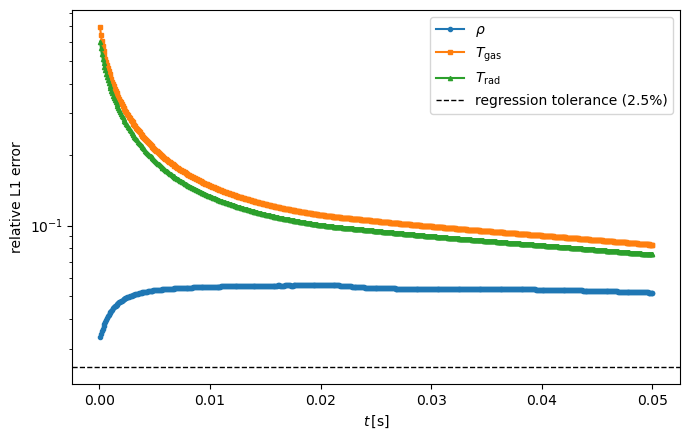

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tab["time"], tab["density_rel_L1"], "o-", ms=3, label=r"$\rho$")
ax.plot(tab["time"], tab["Tgas_rel_L1"], "s-", ms=3, label=r"$T_\mathrm{gas}$")
ax.plot(tab["time"], tab["Trad_rel_L1"], "^-", ms=3, label=r"$T_\mathrm{rad}$")
ax.axhline(0.025, color="k", ls="--", lw=1, label="regression tolerance (2.5%)")
ax.set_xlabel(r"$t\,\mathrm{[s]}$")
ax.set_ylabel("relative L1 error")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()